#**Simulated Anneling**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import pandas as pd
import os
import json
import datetime
from mpl_toolkits.mplot3d import Axes3D
from google.colab import drive
import time

# =========================================================
# 0. Montar Google Drive e definir diretório de saída
# =========================================================
drive.mount('/content/gdrive')
local_path = "/content/gdrive/MyDrive/cpe723"
os.makedirs(local_path, exist_ok=True)
csv_path = os.path.join(local_path, "grid_search_sa_results.csv")
best_record_path = os.path.join(local_path, "best_record_sa.npz")
print("Resultados serão salvos em:")
print(csv_path)
print(best_record_path)

# =========================================================
# 1. Geração de dados sintéticos em R^3
# =========================================================
def generate_data_r3(P=100, NC=8, sigma=0.1, seed=1):
    np.random.seed(seed)
    cluster_centers = np.random.normal(0, 1, (3, NC))
    data_vectors = []
    for k in range(NC):
        centro = cluster_centers[:, k:k+1]
        cluster = sigma * np.random.normal(0, 1, (3, P)) + np.tile(centro, (1, P))
        data_vectors.append(cluster)
    data_vectors = np.concatenate(data_vectors, axis=1)
    return data_vectors, cluster_centers

# =========================================================
# 2. Função custo em R^3 (vetorizada)
# =========================================================
def J(X, Y):
    # diff: (3, N, Kc)
    diff = X[:, :, None] - Y[:, None, :]
    # dist2: (N, Kc)
    dist2 = np.sum(diff * diff, axis=0)
    return np.mean(np.min(dist2, axis=1))

# =========================================================
# 3. Uma execução do Simulated Annealing
# =========================================================
def run_sa(
    data_vectors,
    NC,
    N_iter=1000,
    K_temp=20,
    T0=1.0,
    epsilon=0.5,
    init_seed=0,
    noise_type="gaussian",
    schedule="exp",
    restart_from_best=False
):

    start_time = time.perf_counter()
    np.random.seed(init_seed)
    X = np.random.normal(0, 1, (3, NC))
    JX = J(data_vectors, X)
    Xmin = X.copy()
    Jmin = JX
    total_iters = N_iter * K_temp
    history_J = np.empty(total_iters, dtype=np.float64)
    history_Jmin = np.empty(total_iters, dtype=np.float64)
    history_T = np.empty(total_iters, dtype=np.float64)
    alpha_geo = 0.96
    alpha_exp = 0.5
    idx = 0

    for k in range(K_temp):

        if schedule == "log":
            T = T0 / np.log2(2 + k)
        elif schedule == "linear":
            T = T0 / (1 + k)
        elif schedule == "geometric":
            T = T0 * (alpha_geo ** k)
        elif schedule == "exp":
            T = T0 * np.exp(-alpha_exp * k)
        else:
            raise ValueError("schedule deve ser: 'log', 'linear', 'geometric' ou 'exp'")

        for _ in range(N_iter):
            if noise_type == "gaussian":
                Xhat = X + epsilon * np.random.normal(0, 1, X.shape)
            elif noise_type == "cauchy":
                Xhat = X + epsilon * np.random.standard_cauchy(X.shape)
            else:
                raise ValueError("noise_type deve ser 'gaussian' ou 'cauchy'")

            JXhat = J(data_vectors, Xhat)
            delta = (JX - JXhat) / T
            delta = np.clip(delta, -700, 700)
            accept_prob = np.exp(delta)
            if np.random.uniform() < accept_prob:
                X = Xhat
                JX = JXhat
                if JX < Jmin:
                    Jmin = JX
                    Xmin = X.copy()
            history_J[idx] = JX
            history_Jmin[idx] = Jmin
            history_T[idx] = T
            idx += 1
        if restart_from_best:
            X = Xmin.copy()
            JX = Jmin

    end_time = time.perf_counter()
    duration = end_time - start_time
    print(f"Tempo de execução: {duration:.2f} segundos")

    return Jmin, Xmin, history_J, history_Jmin, history_T

# =========================================================
# 3.1 Função auxiliar para compressão do histórico
# =========================================================
def compress_history(history, N_iter, K_temp, mode="mean"):
    H = history.reshape(K_temp, N_iter)
    if mode == "mean":
        return np.mean(H, axis=0)
    elif mode == "last":
        return H[-1, :]
    elif mode == "min":
        return np.min(H, axis=0)
    elif mode == "max":
        return np.max(H, axis=0)
    else:
        raise ValueError("mode deve ser: mean, last, min ou max")

def compress_temperature_for_plot(history_T, N_iter, K_temp):
    T_stage = history_T.reshape(K_temp, N_iter)[:, 0]
    idx_map = np.linspace(0, K_temp - 1, N_iter).astype(int)
    return T_stage[idx_map]

def compress_cost_for_plot(history, N_iter, K_temp, mode="current"):
    H = history.reshape(K_temp, N_iter)
    idx_map = np.linspace(0, K_temp - 1, N_iter).astype(int)
    out = np.zeros(N_iter)
    for n in range(N_iter):
        out[n] = H[idx_map[n], n]
    return out

# =========================================================
# 4. Grid search
# =========================================================
def grid_search_sa(
    data_vectors,
    cluster_centers,
    NC,
    N_values,
    K_values,
    T0_values,
    epsilon_values,
    seeds=(0,),
    schedule="exp",
    noise_type="gaussian",
    restart_from_best=False,
    csv_path="grid_search_sa_results.csv",
    best_record_path="best_record_sa.npz"
):

    J_global_ref = J(data_vectors, cluster_centers)
    if os.path.exists(csv_path):
        df_existing = pd.read_csv(csv_path)
        tested = set(
            tuple(row)
            for row in df_existing[["N", "K", "T0", "epsilon"]].values
        )
        print(f"{len(df_existing)} linhas já existentes no CSV.")
    else:
        df_existing = pd.DataFrame()
        tested = set()

    combinations = list(itertools.product(N_values, K_values, T0_values, epsilon_values))
    print(f"Total de combinações possíveis: {len(combinations)}")

    best_global_value = np.inf
    if os.path.exists(best_record_path):
        old_best = np.load(best_record_path, allow_pickle=True)
        best_global_value = float(old_best["J_best"])
        print(f"Melhor global prévio encontrado: {best_global_value:.6f}")

    best_record = None
    for idx, (N_iter, K_temp, T0, epsilon) in enumerate(combinations, start=1):
        comb_key = (N_iter, K_temp, T0, epsilon)
        if comb_key in tested:
            print(f"[{idx}/{len(combinations)}] Pulando combinação já calculada: {comb_key}")
            continue

        print("\n==================================================")
        print(f"Combinação {idx}/{len(combinations)}")
        print(f"N={N_iter}, K={K_temp}, T0={T0}, epsilon={epsilon}")

        J_runs = []
        best_run = None
        for seed in seeds:
            print(f"  -> seed {seed}")
            Jmin, Xmin, history_J, history_Jmin, history_T = run_sa(
                data_vectors=data_vectors,
                NC=NC,
                N_iter=N_iter,
                K_temp=K_temp,
                T0=T0,
                epsilon=epsilon,
                init_seed=seed,
                noise_type=noise_type,
                schedule=schedule,
                restart_from_best=restart_from_best
            )
            J_runs.append(Jmin)
            if best_run is None or Jmin < best_run["Jmin"]:
                best_run = {
                    "Jmin": Jmin,
                    "Xmin": Xmin.copy(),
                    "history_J": history_J.copy(),
                    "history_Jmin": history_Jmin.copy(),
                    "history_T": history_T.copy(),
                    "seed": seed
                }
        combo_tag = f"N{N_iter}_K{K_temp}_T0{T0}_eps{epsilon}".replace(".", "p")
        centroids_path = os.path.join(local_path, f"centroids_{combo_tag}.npy")
        history_J_path = os.path.join(local_path, f"history_J_{combo_tag}.npy")
        history_Jmin_path = os.path.join(local_path, f"history_Jmin_{combo_tag}.npy")
        history_T_path = os.path.join(local_path, f"history_T_{combo_tag}.npy")
        np.save(centroids_path, best_run["Xmin"])
        np.save(history_J_path, best_run["history_J"])
        np.save(history_Jmin_path, best_run["history_Jmin"])
        np.save(history_T_path, best_run["history_T"])
        row = {
            "timestamp": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "N": N_iter,
            "K": K_temp,
            "T0": T0,
            "epsilon": epsilon,
            "J_mean": float(np.mean(J_runs)),
            "J_std": float(np.std(J_runs)),
            "J_best": float(np.min(J_runs)),
            "best_seed": int(best_run["seed"]),
            "J_global_reference": float(J_global_ref),
            "centroids_file": centroids_path,
            "history_J_file": history_J_path,
            "history_Jmin_file": history_Jmin_path,
            "history_T_file": history_T_path
        }
        df_row = pd.DataFrame([row])
        write_header = not os.path.exists(csv_path)
        df_row.to_csv(csv_path, mode="a", header=write_header, index=False)

        print("  -> resultado salvo no CSV")
        print(f"  -> centroids: {centroids_path}")
        print(f"  -> history_J: {history_J_path}")
        print(f"  -> history_Jmin: {history_Jmin_path}")
        print(f"  -> history_T: {history_T_path}")

        if row["J_best"] < best_global_value:
            best_global_value = row["J_best"]
            best_record = {
                "N": N_iter,
                "K": K_temp,
                "T0": T0,
                "epsilon": epsilon,
                "J_best": row["J_best"],
                "best_seed": best_run["seed"],
                "best_X": best_run["Xmin"],
                "best_history_J": best_run["history_J"],
                "best_history_Jmin": best_run["history_Jmin"],
                "best_history_T": best_run["history_T"]
            }
            np.savez(
                best_record_path,
                N=N_iter,
                K=K_temp,
                T0=T0,
                epsilon=epsilon,
                J_best=row["J_best"],
                best_seed=best_run["seed"],
                best_X=best_run["Xmin"],
                best_history_J=best_run["history_J"],
                best_history_Jmin=best_run["history_Jmin"],
                best_history_T=best_run["history_T"]
            )

            print("  -> melhor resultado global atualizado e salvo")

    df_results = pd.read_csv(csv_path).sort_values(by="J_best", ascending=True).reset_index(drop=True)
    if best_record is None and os.path.exists(best_record_path):
        loaded = np.load(best_record_path, allow_pickle=True)
        best_record = {
            "N": int(loaded["N"]),
            "K": int(loaded["K"]),
            "T0": float(loaded["T0"]),
            "epsilon": float(loaded["epsilon"]),
            "J_best": float(loaded["J_best"]),
            "best_seed": int(loaded["best_seed"]),
            "best_X": loaded["best_X"],
            "best_history_J": loaded["best_history_J"],
            "best_history_Jmin": loaded["best_history_Jmin"],
            "best_history_T": loaded["best_history_T"]
        }
    return df_results, best_record

# =========================================================
# 5. Plot da melhor solução
# =========================================================
def plot_best_solution_6views(data_vectors, cluster_centers, best_record):

    Xmin = best_record["best_X"]
    history_J = best_record["best_history_J"]
    history_Jmin = best_record["best_history_Jmin"]
    history_T = best_record["best_history_T"]

    N_iter = best_record["N"]
    K_temp = best_record["K"]

    # ======================================
    # Eixo completo: N*K
    # ======================================
    x_full = np.arange(len(history_J))

    # ======================================
    # Compressão para N pontos
    # ======================================
    J_comp = compress_cost_for_plot(history_J, N_iter, K_temp, mode="current")
    Jmin_comp = compress_cost_for_plot(history_Jmin, N_iter, K_temp, mode="best")
    T_comp = compress_temperature_for_plot(history_T, N_iter, K_temp)

    x_comp = np.arange(N_iter)

    # ======================================
    # Temperatura por estágio K
    # ======================================
    T_stage = history_T.reshape(K_temp, N_iter)[:, 0]
    x_stage = np.arange(K_temp)

    # ======================================
    # Figura com 3 gráficos 2D
    # ======================================
    fig, axes = plt.subplots(3, 1, figsize=(12, 16))

    # --------------------------------------
    # 1. Custo completo (N*K) + Temperatura completa (N*K)
    # --------------------------------------
    ax1 = axes[0]
    ax1.plot(x_full, history_J, label="Custo atual", color="tab:blue", alpha=0.5)
    # ax1.plot(x_full, history_Jmin, label="Melhor custo acumulado", color="tab:orange", linewidth=2)
    ax1.set_xlabel("Iteração total (0 ... N×K)")
    ax1.set_ylabel("Custo")
    ax1.set_title("Custo completo + Temperatura completa (N×K)")
    ax1.grid()

    ax1b = ax1.twinx()
    ax1b.plot(x_full, history_T, label="Temperatura completa", color="tab:green", linestyle="--")
    ax1b.set_ylabel("Temperatura")

    # legenda combinada
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1b.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    # --------------------------------------
    # 2. Custo comprimido (N) + Temperatura comprimida (N)
    # --------------------------------------
    ax2 = axes[1]
    ax2.plot(x_comp, J_comp, label="Custo atual comprimido", color="tab:blue", alpha=0.6)
    # ax2.plot(x_comp, Jmin_comp, label="Melhor custo acumulado comprimido", color="tab:orange", linewidth=2)
    ax2.set_xlabel("Iteração interna (0 ... N)")
    ax2.set_ylabel("Custo")
    ax2.set_title("Custo comprimido + Temperatura comprimida (N)")
    ax2.grid()

    ax2b = ax2.twinx()
    ax2b.plot(x_comp, T_comp, label="Temperatura comprimida", color="tab:green", linestyle="--")
    ax2b.set_ylabel("Temperatura")

    # legenda combinada
    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2b.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    # --------------------------------------
    # 3. Temperatura por estágio (K)
    # --------------------------------------
    axes[2].plot(x_stage, T_stage, marker='o')
    axes[2].set_xlabel("Estágio de temperatura k (0 ... K)")
    axes[2].set_ylabel("Temperatura")
    axes[2].set_title("Temperatura por estágio (K)")
    axes[2].grid()

    plt.tight_layout()
    plt.show()

    # ======================================
    # 4. Gráfico 3D
    # ======================================
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(
        data_vectors[0, :],
        data_vectors[1, :],
        data_vectors[2, :],
        c='k',
        s=8,
        alpha=0.25,
        depthshade=False,
        label='Dados'
    )

    ax.scatter(
        Xmin[0, :],
        Xmin[1, :],
        Xmin[2, :],
        c='red',
        s=220,
        marker='o',
        edgecolors='white',
        linewidths=1.8,
        depthshade=False,
        label='Centróides finais'
    )

    ax.scatter(
        cluster_centers[0, :],
        cluster_centers[1, :],
        cluster_centers[2, :],
        c='blue',
        s=260,
        marker='x',
        linewidths=2.5,
        depthshade=False,
        label='Centros verdadeiros'
    )

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("x3")
    ax.set_title("Clustering 3D")
    ax.legend()

    plt.show()



Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Resultados serão salvos em:
/content/gdrive/MyDrive/lps/doutorado/cpe723/projeto1/resultado_sa/grid_search_sa_results.csv
/content/gdrive/MyDrive/lps/doutorado/cpe723/projeto1/resultado_sa/best_record_sa.npz


Custo com centros verdadeiros: 0.030216170273875975
Total de combinações possíveis: 1

Combinação 1/1
N=500, K=32, T0=0.05, epsilon=0.06
  -> seed 5
Tempo de execução: 3.03 segundos
  -> resultado salvo no CSV
  -> centroids: /content/gdrive/MyDrive/lps/doutorado/cpe723/projeto1/resultado_sa/centroids_N500_K32_T00p05_eps0p06.npy
  -> history_J: /content/gdrive/MyDrive/lps/doutorado/cpe723/projeto1/resultado_sa/history_J_N500_K32_T00p05_eps0p06.npy
  -> history_Jmin: /content/gdrive/MyDrive/lps/doutorado/cpe723/projeto1/resultado_sa/history_Jmin_N500_K32_T00p05_eps0p06.npy
  -> history_T: /content/gdrive/MyDrive/lps/doutorado/cpe723/projeto1/resultado_sa/history_T_N500_K32_T00p05_eps0p06.npy
  -> melhor resultado global atualizado e salvo

===== Top 10 combinações =====
             timestamp    N   K    T0  epsilon    J_mean  J_std    J_best  \
0  2026-04-14 23:37:08  500  32  0.05     0.06  0.207014    0.0  0.207014   

   best_seed  J_global_reference  \
0          5            0.030

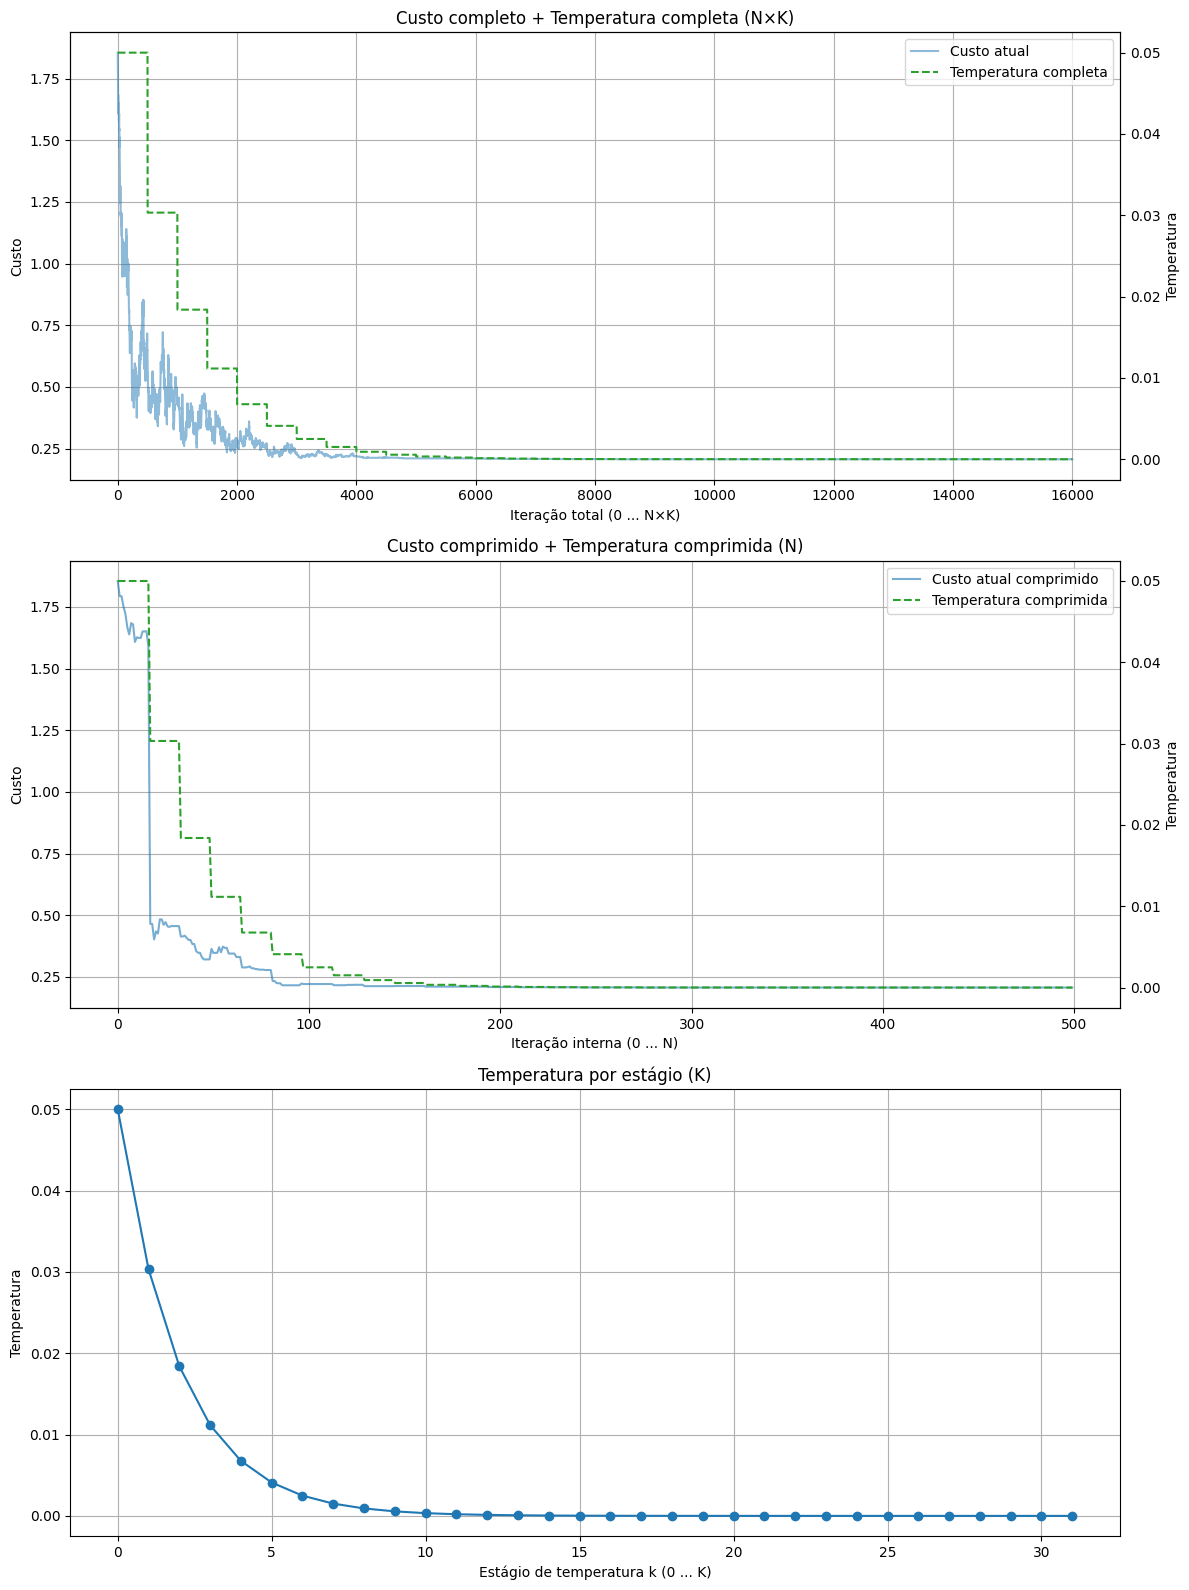

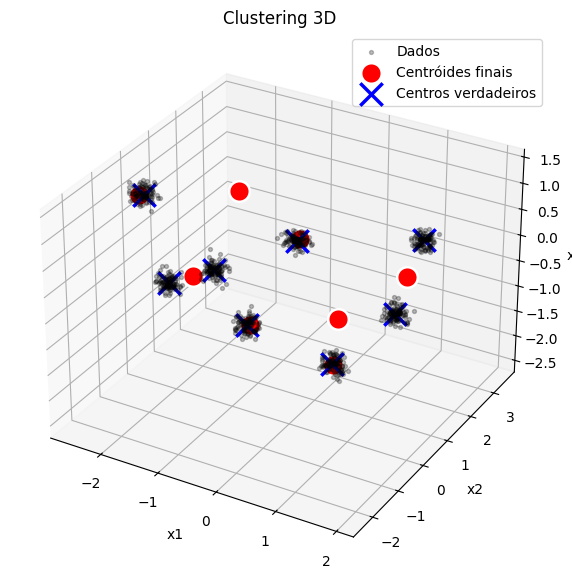

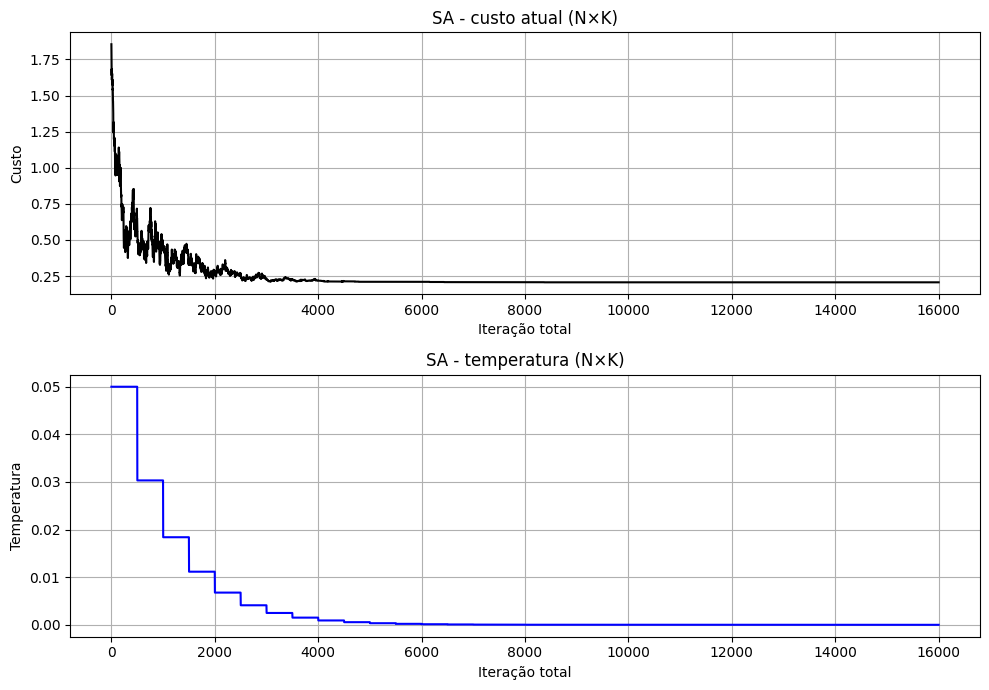

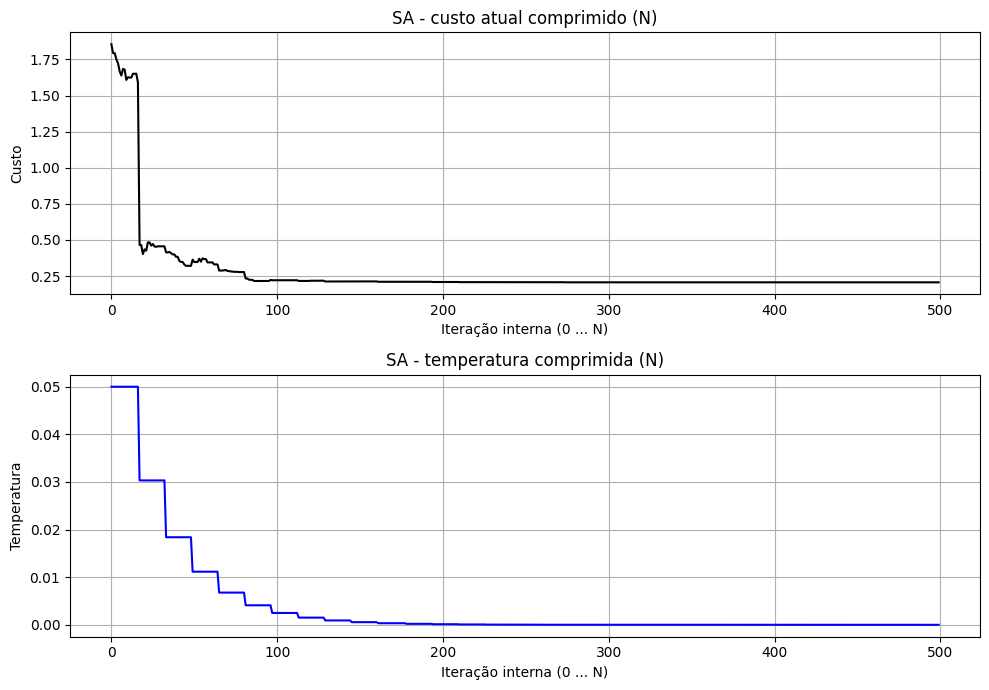

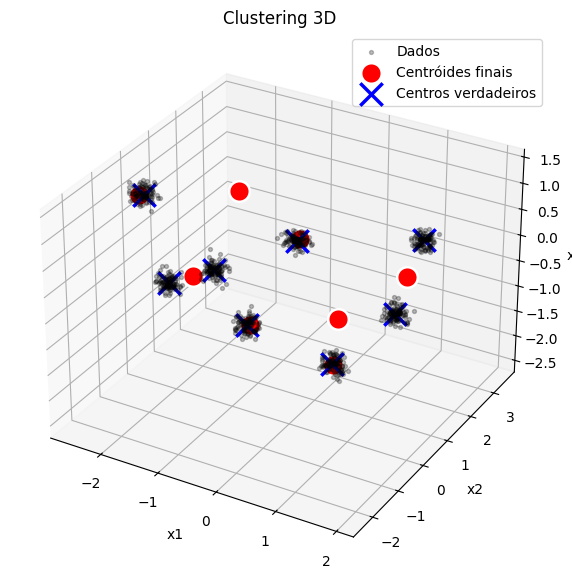

In [ ]:
# =========================================================
# 6. Execução principal
# =========================================================
if __name__ == "__main__":

    NC_number = 8
    data_vectors, cluster_centers = generate_data_r3(P=100, NC=NC_number, sigma=0.1, seed=1)

    J_global_ref = J(data_vectors, cluster_centers)
    print("Custo com centros verdadeiros:", J_global_ref)

    N_values = [500]
    K_values = [32]
    T0_values = [0.05]
    epsilon_values = [0.06]

    df_results, best_record = grid_search_sa(
        data_vectors=data_vectors,
        cluster_centers=cluster_centers,
        NC=NC_number,
        N_values=N_values,
        K_values=K_values,
        T0_values=T0_values,
        epsilon_values=epsilon_values,
        seeds=(5,),
        schedule="exp",
        noise_type="gaussian",
        restart_from_best=False,
        csv_path=csv_path,
        best_record_path=best_record_path
    )

    print("\n===== Top 10 combinações =====")
    print(df_results.head(10))

    print("\n===== Melhor combinação =====")
    print(best_record["N"], best_record["K"], best_record["T0"], best_record["epsilon"])
    print("Melhor custo:", best_record["J_best"])
    print("Melhor seed:", best_record["best_seed"])

    plot_best_solution_6views(data_vectors, cluster_centers, best_record)

# Determinisc Anneling

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Resultados DA serão salvos em:
/content/gdrive/MyDrive/lps/doutorado/cpe723/projeto1/resultado_da/grid_search_da_results.csv
/content/gdrive/MyDrive/lps/doutorado/cpe723/projeto1/resultado_da/best_record_da.npz
Total de combinações possíveis: 1

Combinação 1/1
T0=5.0, alpha=0.9, epsilon=1e-06, delta=0.001, I=200, Tmin=0.1
  -> seed 3
Tempo de execução: 1.91 segundos
             timestamp   T0  alpha   epsilon  delta    I  Tmin    J_mean  \
0  2026-04-14 12:14:25  5.0    0.9  0.000001  0.001  200   0.1  0.028755   

   J_std    J_best  best_seed  J_global_reference  \
0    0.0  0.028755          3            0.028944   

                                      centroids_file  \
0  /content/gdrive/MyDrive/lps/doutorado/cpe723/p...   

                                      history_J_file  \
0  /content/gdrive/MyDrive/lps/doutorado/cpe723/p...   

              

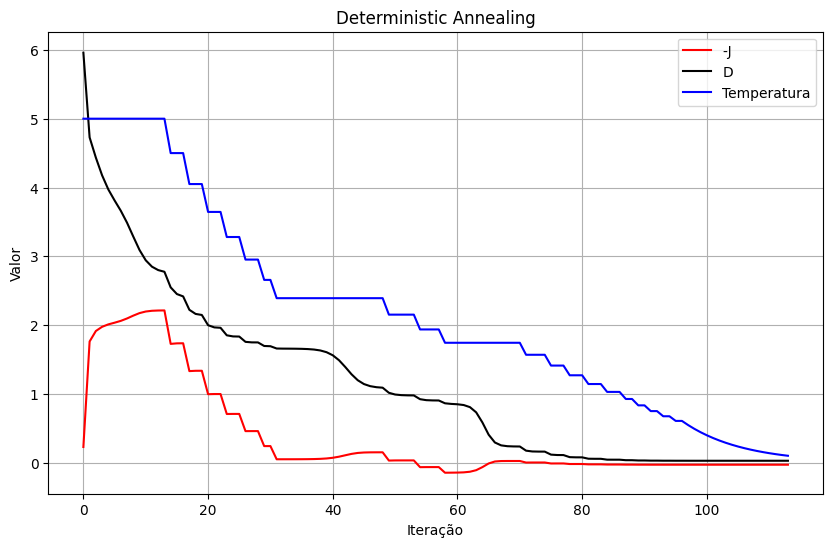

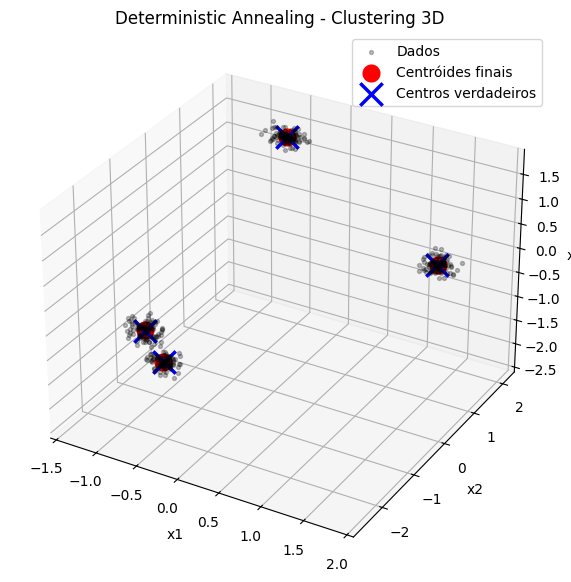

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import pandas as pd
import os
import datetime
from mpl_toolkits.mplot3d import Axes3D
from google.colab import drive
import time

# =========================================================
# 0. Montar Google Drive e definir diretório de saída
# =========================================================
drive.mount('/content/gdrive')
local_path = "/content/gdrive/MyDrive/cpe723"
os.makedirs(local_path, exist_ok=True)
csv_path_da = os.path.join(local_path, "grid_search_da_results.csv")
best_record_path_da = os.path.join(local_path, "best_record_da.npz")
print("Resultados DA serão salvos em:")
print(csv_path_da)
print(best_record_path_da)

# =========================================================
# 1. Geração de dados sintéticos em R^3
# =========================================================
def generate_data_r3(P=100, NC=8, sigma=0.1, seed=1):
    np.random.seed(seed)
    cluster_centers = np.random.normal(0, 1, (3, NC))
    data_vectors = []
    for k in range(NC):
        centro = cluster_centers[:, k:k+1]
        cluster = sigma * np.random.normal(0, 1, (3, P)) + np.tile(centro, (1, P))
        data_vectors.append(cluster)
    data_vectors = np.concatenate(data_vectors, axis=1)
    return data_vectors, cluster_centers

# =========================================================
# 2. Função custo "hard" só para referência
# =========================================================
def J_hard(X, Y):
    diff = X[:, :, None] - Y[:, None, :]
    dist2 = np.sum(diff**2, axis=0)   # (N, K)
    return np.mean(np.min(dist2, axis=1))

# =========================================================
# 3. Uma execução do Deterministic Annealing
# =========================================================
def run_da(
    data_vectors,
    NC,
    T0=10.0,
    alpha=0.9,
    epsilon=1e-6,
    delta=1e-3,
    I=200,
    Tmin=0.1,
    init_seed=0
):
    start_time = time.perf_counter()
    np.random.seed(init_seed)
    X = data_vectors
    M, N = X.shape
    K = NC
    Y = np.random.normal(0, 1, (M, K))
    Y_best = Y.copy()
    T = T0
    fim = False
    i = 0
    d = np.zeros((K, N))
    p_ygivenx = np.zeros((K, N))
    history_J = np.zeros(I)
    history_D = np.zeros(I)
    history_T = np.zeros(I)
    history_Jbest = np.zeros(I)
    D_best = np.inf

    while not fim:
        for n in range(N):
            for k in range(K):
                d[k, n] = np.sum((X[:, n] - Y[:, k])**2)
                p_ygivenx[k, n] = np.exp(-d[k, n] / T)

        Zx = np.sum(p_ygivenx, axis=0)
        p_ygivenx = p_ygivenx / np.tile(Zx, (K, 1))

        Y_new = np.zeros((M, K))
        for k in range(K):
            y = np.zeros(M)
            w = 0.0
            for n in range(N):
                y += p_ygivenx[k, n] * X[:, n]
                w += p_ygivenx[k, n]
            Y_new[:, k] = y / w

        Y = Y_new

        J_val = -T / N * np.sum(np.log(Zx))
        D_val = np.mean(np.sum(p_ygivenx * d, axis=0))

        history_J[i] = J_val
        history_D[i] = D_val
        history_T[i] = T

        if D_val < D_best:
            D_best = D_val
            Y_best = Y.copy()

        history_Jbest[i] = D_best

        if i > 0:
            rel_change = abs(history_J[i] - history_J[i-1]) / max(abs(history_J[i-1]), 1e-12)
            if rel_change < delta:
                T = alpha * T
                Y = Y + epsilon * np.random.normal(0, 1, Y.shape)

        i += 1

        if (T < Tmin) or (i == I):
            fim = True

    end_time = time.perf_counter()
    duration = end_time - start_time
    print(f"Tempo de execução: {duration:.2f} segundos")

    history_J = history_J[:i]
    history_D = history_D[:i]
    history_T = history_T[:i]
    history_Jbest = history_Jbest[:i]

    return D_best, Y_best, history_J, history_D, history_T, history_Jbest

# =========================================================
# 3.1 Uma execução do Deterministic Annealing - Versão Otimizada
# =========================================================
def run_da_fast(
    data_vectors,
    NC,
    T0=10.0,
    alpha=0.9,
    epsilon=1e-6,
    delta=1e-3,
    I=200,
    Tmin=0.1,
    init_seed=0
):

    np.random.seed(init_seed)
    X = data_vectors
    M, N = X.shape
    K = NC
    Y = np.random.normal(0, 1, (M, K))
    Y_best = Y.copy()
    T = T0

    history_J = np.zeros(I)
    history_D = np.zeros(I)
    history_T = np.zeros(I)
    history_Dbest = np.zeros(I)

    D_best = np.inf

    for i in range(I):
        diff = X[:, :, None] - Y[:, None, :]
        d = np.sum(diff**2, axis=0)
        p = np.exp(-d / T)

        Zx = np.sum(p, axis=0)
        p /= Zx
        weights = np.sum(p, axis=1)
        Y = (X @ p.T) / weights
        J_val = -T/N * np.sum(np.log(Zx))
        D_val = np.mean(np.sum(p * d, axis=0))

        history_J[i] = J_val
        history_D[i] = D_val
        history_T[i] = T

        if D_val < D_best:
            D_best = D_val
            Y_best = Y.copy()

        history_Dbest[i] = D_best

        if i > 0:
            rel_change = abs(history_J[i] - history_J[i-1]) / max(abs(history_J[i-1]), 1e-12)
            if rel_change < delta:
                T *= alpha
                Y += epsilon * np.random.normal(0, 1, Y.shape)
        if T < Tmin:
            break

    return (
        D_best,
        Y_best,
        history_J[:i+1],
        history_D[:i+1],
        history_T[:i+1],
        history_Dbest[:i+1]
    )

# =========================================================
# 4. Grid search para DA
# =========================================================
def grid_search_da(
    data_vectors,
    cluster_centers,
    NC,
    T0_values,
    alpha_values,
    epsilon_values,
    delta_values,
    I_values,
    Tmin_values,
    seeds=(0, 1, 2),
    csv_path="grid_search_da_results.csv",
    best_record_path="best_record_da.npz"
):
    J_global_ref = J_hard(data_vectors, cluster_centers)

    if os.path.exists(csv_path):
        df_existing = pd.read_csv(csv_path)
        tested = set(
            tuple(row)
            for row in df_existing[["T0", "alpha", "epsilon", "delta", "I", "Tmin"]].values
        )
        print(f"{len(df_existing)} linhas já existentes no CSV.")
    else:
        df_existing = pd.DataFrame()
        tested = set()

    combinations = list(itertools.product(
        T0_values, alpha_values, epsilon_values, delta_values, I_values, Tmin_values
    ))

    print(f"Total de combinações possíveis: {len(combinations)}")

    best_global_value = np.inf
    if os.path.exists(best_record_path):
        old_best = np.load(best_record_path, allow_pickle=True)
        best_global_value = float(old_best["J_best"])
        print(f"Melhor global prévio encontrado: {best_global_value:.6f}")

    best_record = None

    for idx, (T0, alpha, epsilon, delta, I, Tmin) in enumerate(combinations, start=1):
        comb_key = (T0, alpha, epsilon, delta, I, Tmin)

        if comb_key in tested:
            print(f"[{idx}/{len(combinations)}] Pulando combinação já calculada: {comb_key}")
            continue

        print("\n==================================================")
        print(f"Combinação {idx}/{len(combinations)}")
        print(f"T0={T0}, alpha={alpha}, epsilon={epsilon}, delta={delta}, I={I}, Tmin={Tmin}")

        J_runs = []
        best_run = None

        for seed in seeds:
            print(f"  -> seed {seed}")

            D_best, Y_best, history_J, history_D, history_T, history_Jbest = run_da(
                data_vectors=data_vectors,
                NC=NC,
                T0=T0,
                alpha=alpha,
                epsilon=epsilon,
                delta=delta,
                I=I,
                Tmin=Tmin,
                init_seed=seed
            )

            J_runs.append(D_best)

            if best_run is None or D_best < best_run["J_best"]:
                best_run = {
                    "J_best": D_best,
                    "best_X": Y_best.copy(),
                    "history_J": history_J.copy(),
                    "history_D": history_D.copy(),
                    "history_T": history_T.copy(),
                    "history_Jbest": history_Jbest.copy(),
                    "seed": seed
                }

        combo_tag = f"T0{T0}_a{alpha}_e{epsilon}_d{delta}_I{I}_Tmin{Tmin}".replace(".", "p")

        centroids_path = os.path.join(local_path, f"da_centroids_{combo_tag}.npy")
        history_J_path = os.path.join(local_path, f"da_history_J_{combo_tag}.npy")
        history_D_path = os.path.join(local_path, f"da_history_D_{combo_tag}.npy")
        history_T_path = os.path.join(local_path, f"da_history_T_{combo_tag}.npy")
        history_Jbest_path = os.path.join(local_path, f"da_history_Jbest_{combo_tag}.npy")

        np.save(centroids_path, best_run["best_X"])
        np.save(history_J_path, best_run["history_J"])
        np.save(history_D_path, best_run["history_D"])
        np.save(history_T_path, best_run["history_T"])
        np.save(history_Jbest_path, best_run["history_Jbest"])

        row = {
            "timestamp": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "T0": T0,
            "alpha": alpha,
            "epsilon": epsilon,
            "delta": delta,
            "I": I,
            "Tmin": Tmin,
            "J_mean": float(np.mean(J_runs)),
            "J_std": float(np.std(J_runs)),
            "J_best": float(np.min(J_runs)),
            "best_seed": int(best_run["seed"]),
            "J_global_reference": float(J_global_ref),
            "centroids_file": centroids_path,
            "history_J_file": history_J_path,
            "history_D_file": history_D_path,
            "history_T_file": history_T_path,
            "history_Jbest_file": history_Jbest_path
        }

        df_row = pd.DataFrame([row])
        write_header = not os.path.exists(csv_path)
        df_row.to_csv(csv_path, mode="a", header=write_header, index=False)

        if row["J_best"] < best_global_value:
            best_global_value = row["J_best"]
            best_record = {
                "T0": T0,
                "alpha": alpha,
                "epsilon": epsilon,
                "delta": delta,
                "I": I,
                "Tmin": Tmin,
                "J_best": row["J_best"],
                "best_seed": best_run["seed"],
                "best_X": best_run["best_X"],
                "best_history_J": best_run["history_J"],
                "best_history_D": best_run["history_D"],
                "best_history_T": best_run["history_T"],
                "best_history_Jbest": best_run["history_Jbest"]
            }

            np.savez(
                best_record_path,
                T0=T0,
                alpha=alpha,
                epsilon=epsilon,
                delta=delta,
                I=I,
                Tmin=Tmin,
                J_best=row["J_best"],
                best_seed=best_run["seed"],
                best_X=best_run["best_X"],
                best_history_J=best_run["history_J"],
                best_history_D=best_run["history_D"],
                best_history_T=best_run["history_T"],
                best_history_Jbest=best_run["history_Jbest"]
            )

    df_results = pd.read_csv(csv_path).sort_values(by="J_best", ascending=True).reset_index(drop=True)

    if best_record is None and os.path.exists(best_record_path):
        loaded = np.load(best_record_path, allow_pickle=True)
        best_record = {
            "T0": float(loaded["T0"]),
            "alpha": float(loaded["alpha"]),
            "epsilon": float(loaded["epsilon"]),
            "delta": float(loaded["delta"]),
            "I": int(loaded["I"]),
            "Tmin": float(loaded["Tmin"]),
            "J_best": float(loaded["J_best"]),
            "best_seed": int(loaded["best_seed"]),
            "best_X": loaded["best_X"],
            "best_history_J": loaded["best_history_J"],
            "best_history_D": loaded["best_history_D"],
            "best_history_T": loaded["best_history_T"],
            "best_history_Jbest": loaded["best_history_Jbest"]
        }

    return df_results, best_record

# =========================================================
# 5. Plot DA
# =========================================================
def plot_best_solution_da(data_vectors, cluster_centers, best_record):
    Xbest = best_record["best_X"]
    history_J = best_record["best_history_J"]
    history_D = best_record["best_history_D"]
    history_T = best_record["best_history_T"]

    plt.figure(figsize=(10, 6))
    plt.plot(-history_J, 'r-', label='-J')
    plt.plot(history_D, 'k-', label='D')
    plt.plot(history_T, 'b-', label='Temperatura')
    plt.grid()
    plt.xlabel('Iteração')
    plt.ylabel('Valor')
    plt.title('Deterministic Annealing')
    plt.legend()
    plt.show()

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(
        data_vectors[0, :],
        data_vectors[1, :],
        data_vectors[2, :],
        c='k',
        s=8,
        alpha=0.25,
        depthshade=False,
        label='Dados'
    )

    ax.scatter(
        Xbest[0, :],
        Xbest[1, :],
        Xbest[2, :],
        c='red',
        s=220,
        marker='o',
        edgecolors='white',
        linewidths=1.8,
        depthshade=False,
        label='Centróides finais'
    )

    ax.scatter(
        cluster_centers[0, :],
        cluster_centers[1, :],
        cluster_centers[2, :],
        c='blue',
        s=260,
        marker='x',
        linewidths=2.5,
        depthshade=False,
        label='Centros verdadeiros'
    )

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("x3")
    ax.set_title("Deterministic Annealing - Clustering 3D")
    ax.legend()
    plt.show()


if __name__ == "__main__":

    NC_number = 4

    data_vectors, cluster_centers = generate_data_r3(P=100, NC=NC_number, sigma=0.1, seed=1)

    df_results, best_record = grid_search_da(
        data_vectors=data_vectors,
        cluster_centers=cluster_centers,
        NC=NC_number,
        T0_values=[5.0],
        alpha_values=[0.90],
        epsilon_values=[1e-6],
        delta_values=[1e-3],
        I_values=[200],
        Tmin_values=[0.1],
        seeds=(3,),
        csv_path=csv_path_da,
        best_record_path=best_record_path_da
    )

    print(df_results.head(10))
    print(best_record["T0"], best_record["alpha"], best_record["J_best"])

    plot_best_solution_da(data_vectors, cluster_centers, best_record)

# Otimizar tempo SA

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Resultados serão salvos em:
/content/gdrive/MyDrive/lps/doutorado/cpe723/projeto1/resultado_sa/grid_search_sa_results.csv
/content/gdrive/MyDrive/lps/doutorado/cpe723/projeto1/resultado_sa/best_record_sa.npz
Custo com centros verdadeiros: 0.030216170273875975
Total de combinações possíveis: 1

Combinação 1/1
N=500, K=32, T0=0.05, epsilon=0.06
  -> seed 18
Tempo de execução: 1.20 segundos
  -> resultado salvo no CSV
  -> centroids: /content/gdrive/MyDrive/lps/doutorado/cpe723/projeto1/resultado_sa/centroids_N500_K32_T00p05_eps0p06.npy
  -> history_J: /content/gdrive/MyDrive/lps/doutorado/cpe723/projeto1/resultado_sa/history_J_N500_K32_T00p05_eps0p06.npy
  -> history_Jmin: /content/gdrive/MyDrive/lps/doutorado/cpe723/projeto1/resultado_sa/history_Jmin_N500_K32_T00p05_eps0p06.npy
  -> history_T: /content/gdrive/MyDrive/lps/doutorado/cpe723/projeto1/resultado_s

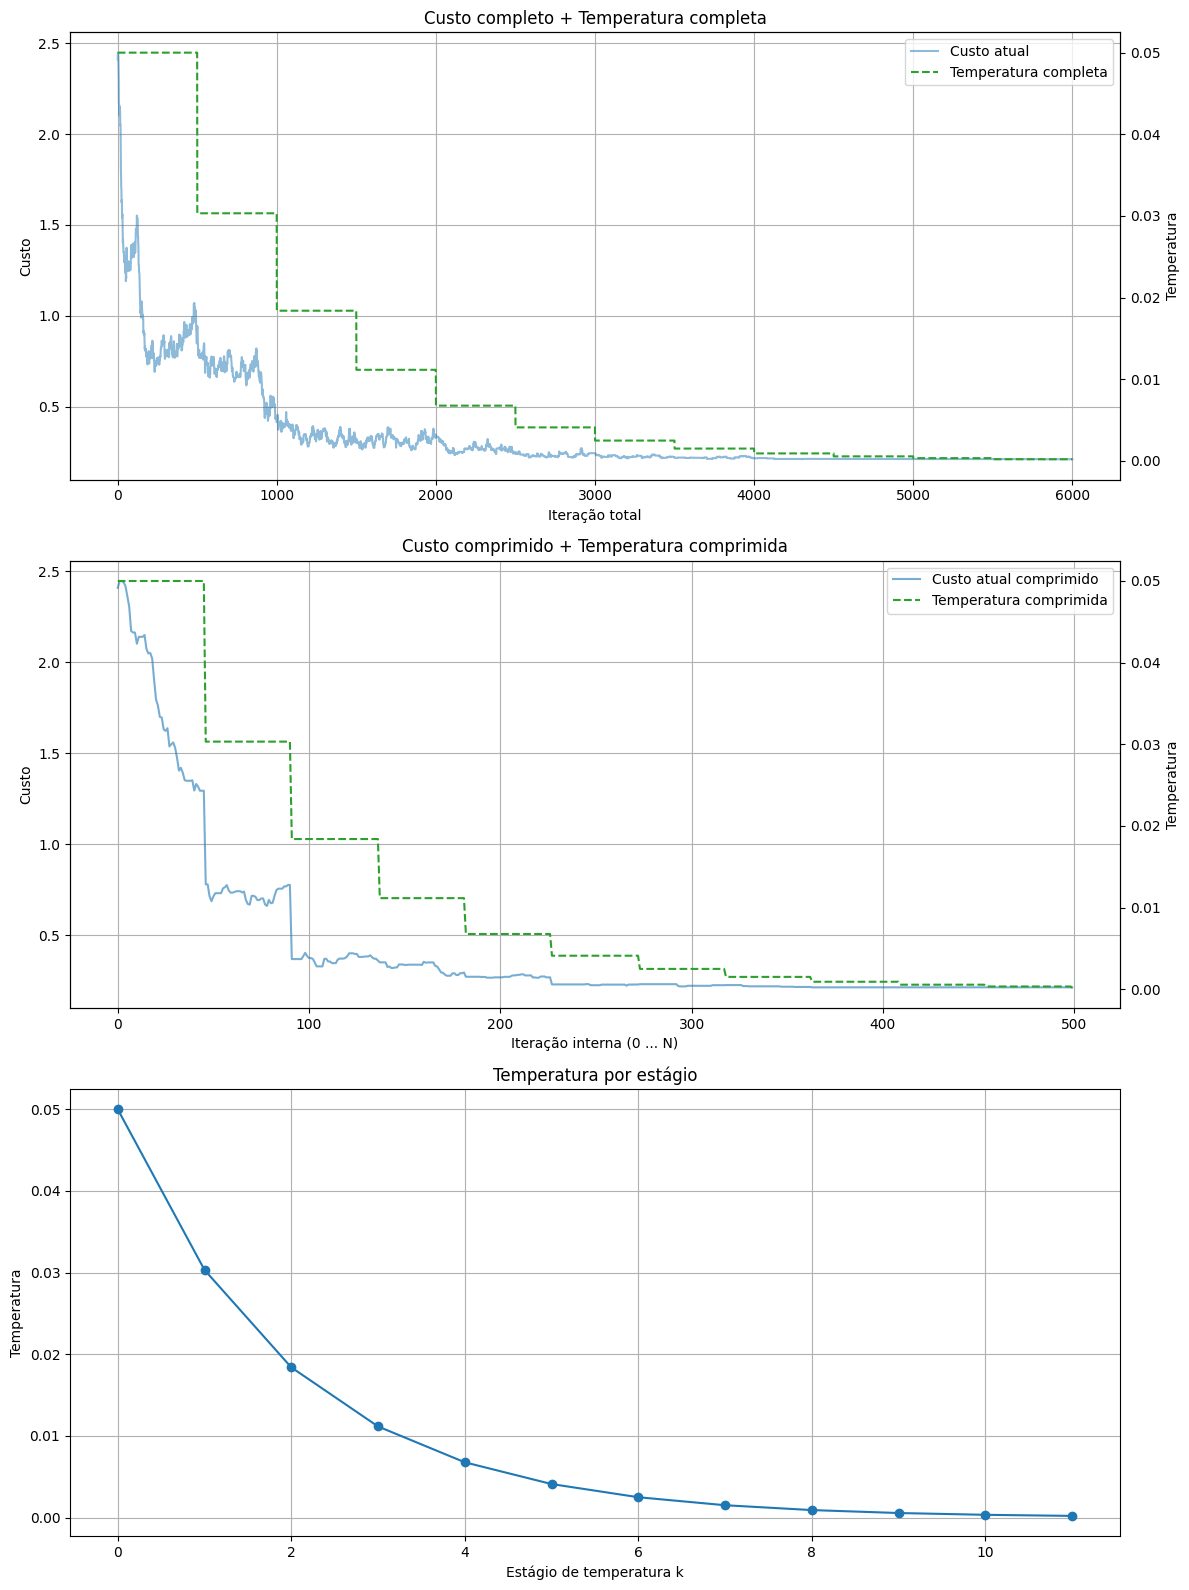

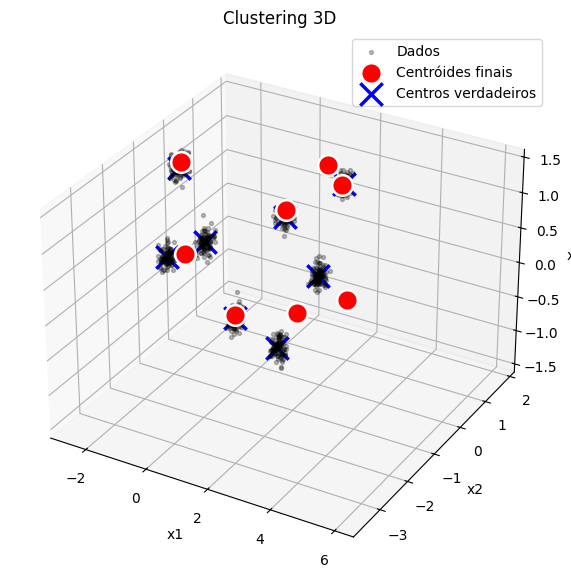

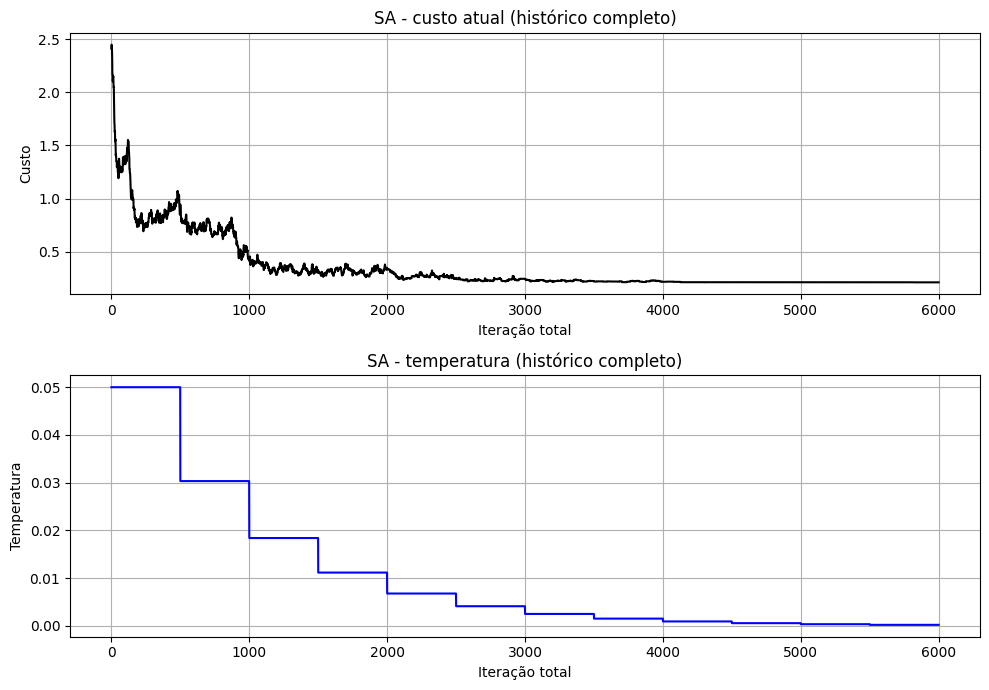

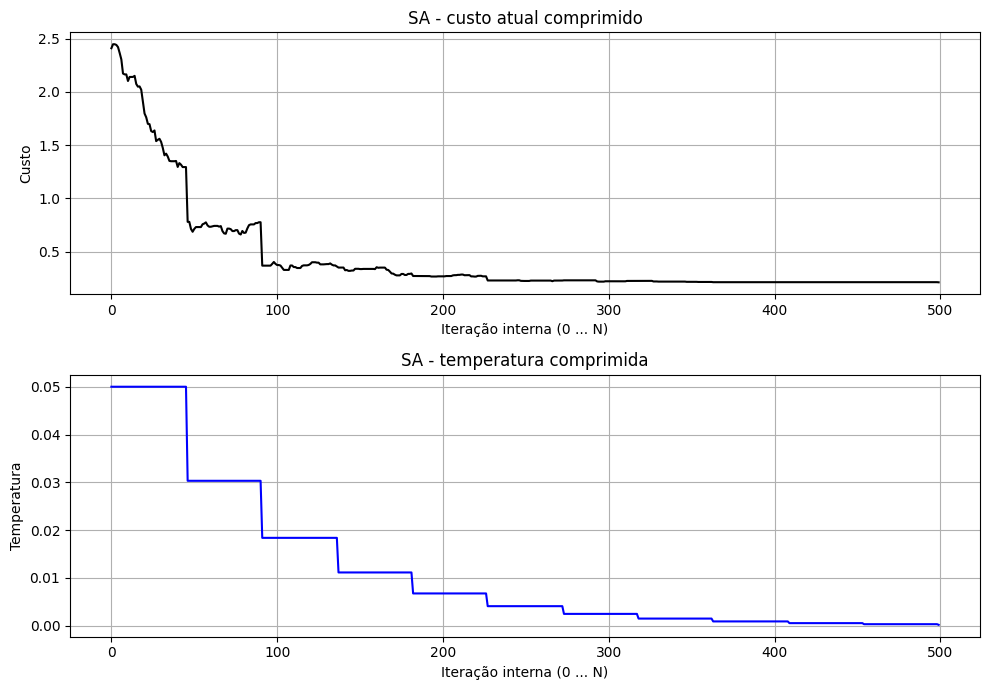

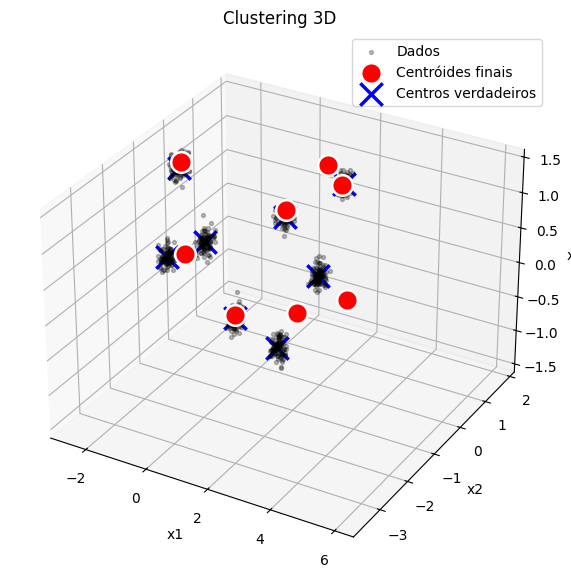

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import pandas as pd
import os
import json
import datetime
from mpl_toolkits.mplot3d import Axes3D
from google.colab import drive
import time

# =========================================================
# 0. Montar Google Drive e definir diretório de saída
# =========================================================
drive.mount('/content/gdrive')
local_path = "/content/gdrive/MyDrive/cpe723/resultado_sa"
os.makedirs(local_path, exist_ok=True)
csv_path = os.path.join(local_path, "grid_search_sa_results.csv")
best_record_path = os.path.join(local_path, "best_record_sa.npz")
print("Resultados serão salvos em:")
print(csv_path)
print(best_record_path)

# =========================================================
# 1. Geração de dados sintéticos em R^3
# =========================================================
def generate_data_r3(P=100, NC=8, sigma=0.1, seed=1):
    np.random.seed(seed)
    cluster_centers = np.random.normal(0, 1, (3, NC))
    data_vectors = []
    for k in range(NC):
        centro = cluster_centers[:, k:k+1]
        cluster = sigma * np.random.normal(0, 1, (3, P)) + np.tile(centro, (1, P))
        data_vectors.append(cluster)
    data_vectors = np.concatenate(data_vectors, axis=1)
    return data_vectors, cluster_centers

# =========================================================
# 2. Função custo em R^3 (vetorizada)
# =========================================================
def J(X, Y):
    diff = X[:, :, None] - Y[:, None, :]
    dist2 = np.sum(diff * diff, axis=0)
    return np.mean(np.min(dist2, axis=1))

# =========================================================
# 3. Uma execução do Simulated Annealing (otimizada)
# =========================================================
def run_sa(
    data_vectors,
    NC,
    N_iter=1000,
    K_temp=20,
    T0=1.0,
    epsilon=0.5,
    init_seed=0,
    noise_type="gaussian",
    schedule="exp",
    restart_from_best=False,
    delta=1e-3,
    Tmin=0.005,
    patience=3
):

    start_time = time.perf_counter()
    np.random.seed(init_seed)
    X = np.random.normal(0, 1, (3, NC))
    JX = J(data_vectors, X)
    Xmin = X.copy()
    Jmin = JX
    total_iters = N_iter * K_temp
    history_J = np.empty(total_iters, dtype=np.float64)
    history_Jmin = np.empty(total_iters, dtype=np.float64)
    history_T = np.empty(total_iters, dtype=np.float64)
    alpha_geo = 0.96
    alpha_exp = 0.5
    idx = 0
    prev_stage_best = None
    no_improve_count = 0

    for k in range(K_temp):
        if schedule == "log":
            T = T0 / np.log2(2 + k)
        elif schedule == "linear":
            T = T0 / (1 + k)
        elif schedule == "geometric":
            T = T0 * (alpha_geo ** k)
        elif schedule == "exp":
            T = T0 * np.exp(-alpha_exp * k)
        else:
            raise ValueError("schedule deve ser: 'log', 'linear', 'geometric' ou 'exp'")

        for _ in range(N_iter):
            if noise_type == "gaussian":
                Xhat = X + epsilon * np.random.normal(0, 1, X.shape)
            elif noise_type == "cauchy":
                Xhat = X + epsilon * np.random.standard_cauchy(X.shape)
            else:
                raise ValueError("noise_type deve ser 'gaussian' ou 'cauchy'")

            JXhat = J(data_vectors, Xhat)
            delta_cost = (JX - JXhat) / max(T, 1e-12)
            delta_cost = np.clip(delta_cost, -700, 700)
            accept_prob = np.exp(delta_cost)

            if np.random.uniform() < accept_prob:
                X = Xhat
                JX = JXhat
                if JX < Jmin:
                    Jmin = JX
                    Xmin = X.copy()

            history_J[idx] = JX
            history_Jmin[idx] = Jmin
            history_T[idx] = T
            idx += 1

        if restart_from_best:
            X = Xmin.copy()
            JX = Jmin

        stage_best_after = Jmin
        if prev_stage_best is not None:
            rel_change = abs(prev_stage_best - stage_best_after) / max(abs(prev_stage_best), 1e-12)
            if rel_change < delta:
                no_improve_count += 1
            else:
                no_improve_count = 0
        prev_stage_best = stage_best_after
        if (T < Tmin) and (no_improve_count >= patience):
            break

    n_stages_done = k + 1

    end_time = time.perf_counter()
    duration = end_time - start_time
    print(f"Tempo de execução: {duration:.2f} segundos")

    return (
        Jmin,
        Xmin,
        history_J[:idx],
        history_Jmin[:idx],
        history_T[:idx],
        n_stages_done
    )


# =========================================================
# 3.1 Função auxiliar para compressão do histórico
# =========================================================
def compress_history(history, N_iter, n_stages_done, mode="mean"):
    H = history.reshape(n_stages_done, N_iter)
    if mode == "mean":
        return np.mean(H, axis=0)
    elif mode == "last":
        return H[-1, :]
    elif mode == "min":
        return np.min(H, axis=0)
    elif mode == "max":
        return np.max(H, axis=0)
    else:
        raise ValueError("mode deve ser: mean, last, min ou max")

def compress_temperature_for_plot(history_T, N_iter, n_stages_done):
    T_stage = history_T.reshape(n_stages_done, N_iter)[:, 0]
    idx_map = np.linspace(0, n_stages_done - 1, N_iter).astype(int)
    return T_stage[idx_map]


def compress_cost_for_plot(history, N_iter, n_stages_done, mode="current"):
    H = history.reshape(n_stages_done, N_iter)
    idx_map = np.linspace(0, n_stages_done - 1, N_iter).astype(int)
    out = np.zeros(N_iter)
    for n in range(N_iter):
        out[n] = H[idx_map[n], n]
    return out

# =========================================================
# 4. Grid search
# =========================================================
def grid_search_sa(
    data_vectors,
    cluster_centers,
    NC,
    N_values,
    K_values,
    T0_values,
    epsilon_values,
    seeds=(0,),
    schedule="exp",
    noise_type="gaussian",
    restart_from_best=False,
    csv_path="grid_search_sa_results.csv",
    best_record_path="best_record_sa.npz"
):

    J_global_ref = J(data_vectors, cluster_centers)
    if os.path.exists(csv_path):
        df_existing = pd.read_csv(csv_path)
        tested = set(
            tuple(row)
            for row in df_existing[["N", "K", "T0", "epsilon"]].values
        )
        print(f"{len(df_existing)} linhas já existentes no CSV.")
    else:
        df_existing = pd.DataFrame()
        tested = set()

    combinations = list(itertools.product(N_values, K_values, T0_values, epsilon_values))
    print(f"Total de combinações possíveis: {len(combinations)}")

    best_global_value = np.inf
    if os.path.exists(best_record_path):
        old_best = np.load(best_record_path, allow_pickle=True)
        best_global_value = float(old_best["J_best"])
        print(f"Melhor global prévio encontrado: {best_global_value:.6f}")

    best_record = None
    for idx, (N_iter, K_temp, T0, epsilon) in enumerate(combinations, start=1):
        comb_key = (N_iter, K_temp, T0, epsilon)

        if comb_key in tested:
            print(f"[{idx}/{len(combinations)}] Pulando combinação já calculada: {comb_key}")
            continue

        print("\n==================================================")
        print(f"Combinação {idx}/{len(combinations)}")
        print(f"N={N_iter}, K={K_temp}, T0={T0}, epsilon={epsilon}")

        J_runs = []
        best_run = None
        for seed in seeds:
            print(f"  -> seed {seed}")
            Jmin, Xmin, history_J, history_Jmin, history_T, n_stages_done = run_sa(
                data_vectors=data_vectors,
                NC=NC,
                N_iter=N_iter,
                K_temp=K_temp,
                T0=T0,
                epsilon=epsilon,
                init_seed=seed,
                noise_type=noise_type,
                schedule=schedule,
                restart_from_best=restart_from_best,
                delta=1e-3,
                Tmin=0.005,
                patience=3
            )

            J_runs.append(Jmin)

            if best_run is None or Jmin < best_run["Jmin"]:
                best_run = {
                    "Jmin": Jmin,
                    "Xmin": Xmin.copy(),
                    "history_J": history_J.copy(),
                    "history_Jmin": history_Jmin.copy(),
                    "history_T": history_T.copy(),
                    "seed": seed,
                    "n_stages_done": n_stages_done
                }

        combo_tag = f"N{N_iter}_K{K_temp}_T0{T0}_eps{epsilon}".replace(".", "p")

        centroids_path = os.path.join(local_path, f"centroids_{combo_tag}.npy")
        history_J_path = os.path.join(local_path, f"history_J_{combo_tag}.npy")
        history_Jmin_path = os.path.join(local_path, f"history_Jmin_{combo_tag}.npy")
        history_T_path = os.path.join(local_path, f"history_T_{combo_tag}.npy")

        np.save(centroids_path, best_run["Xmin"])
        np.save(history_J_path, best_run["history_J"])
        np.save(history_Jmin_path, best_run["history_Jmin"])
        np.save(history_T_path, best_run["history_T"])

        row = {
            "timestamp": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "N": N_iter,
            "K": K_temp,
            "T0": T0,
            "epsilon": epsilon,
            "J_mean": float(np.mean(J_runs)),
            "J_std": float(np.std(J_runs)),
            "J_best": float(np.min(J_runs)),
            "best_seed": int(best_run["seed"]),
            "n_stages_done": int(best_run["n_stages_done"]),
            "J_global_reference": float(J_global_ref),
            "centroids_file": centroids_path,
            "history_J_file": history_J_path,
            "history_Jmin_file": history_Jmin_path,
            "history_T_file": history_T_path
        }

        df_row = pd.DataFrame([row])

        write_header = not os.path.exists(csv_path)
        df_row.to_csv(csv_path, mode="a", header=write_header, index=False)

        print("  -> resultado salvo no CSV")
        print(f"  -> centroids: {centroids_path}")
        print(f"  -> history_J: {history_J_path}")
        print(f"  -> history_Jmin: {history_Jmin_path}")
        print(f"  -> history_T: {history_T_path}")

        if row["J_best"] < best_global_value:
            best_global_value = row["J_best"]
            best_record = {
                "N": N_iter,
                "K": K_temp,
                "T0": T0,
                "epsilon": epsilon,
                "J_best": row["J_best"],
                "best_seed": best_run["seed"],
                "best_X": best_run["Xmin"],
                "best_history_J": best_run["history_J"],
                "best_history_Jmin": best_run["history_Jmin"],
                "best_history_T": best_run["history_T"],
                "n_stages_done": best_run["n_stages_done"]
            }

            np.savez(
                best_record_path,
                N=N_iter,
                K=K_temp,
                T0=T0,
                epsilon=epsilon,
                J_best=row["J_best"],
                best_seed=best_run["seed"],
                best_X=best_run["Xmin"],
                best_history_J=best_run["history_J"],
                best_history_Jmin=best_run["history_Jmin"],
                best_history_T=best_run["history_T"],
                n_stages_done=best_run["n_stages_done"]
            )

            print("  -> melhor resultado global atualizado e salvo")

    df_results = pd.read_csv(csv_path).sort_values(by="J_best", ascending=True).reset_index(drop=True)

    if best_record is None and os.path.exists(best_record_path):
        loaded = np.load(best_record_path, allow_pickle=True)
        best_record = {
            "N": int(loaded["N"]),
            "K": int(loaded["K"]),
            "T0": float(loaded["T0"]),
            "epsilon": float(loaded["epsilon"]),
            "J_best": float(loaded["J_best"]),
            "best_seed": int(loaded["best_seed"]),
            "best_X": loaded["best_X"],
            "best_history_J": loaded["best_history_J"],
            "best_history_Jmin": loaded["best_history_Jmin"],
            "best_history_T": loaded["best_history_T"],
            "n_stages_done": int(loaded["n_stages_done"])
        }

    return df_results, best_record

# =========================================================
# 5. Plot da melhor solução
# =========================================================
def plot_best_solution_6views(data_vectors, cluster_centers, best_record):

    Xmin = best_record["best_X"]
    history_J = best_record["best_history_J"]
    history_Jmin = best_record["best_history_Jmin"]
    history_T = best_record["best_history_T"]

    N_iter = best_record["N"]
    n_stages_done = best_record["n_stages_done"]

    # ======================================
    # Eixo completo: número real de iterações executadas
    # ======================================
    x_full = np.arange(len(history_J))

    # ======================================
    # Compressão para N pontos
    # ======================================
    J_comp = compress_cost_for_plot(history_J, N_iter, n_stages_done, mode="current")
    Jmin_comp = compress_cost_for_plot(history_Jmin, N_iter, n_stages_done, mode="best")
    T_comp = compress_temperature_for_plot(history_T, N_iter, n_stages_done)

    x_comp = np.arange(N_iter)

    # ======================================
    # Temperatura por estágio executado
    # ======================================
    T_stage = history_T.reshape(n_stages_done, N_iter)[:, 0]
    x_stage = np.arange(n_stages_done)

    # ======================================
    # Figura com 3 gráficos 2D
    # ======================================
    fig, axes = plt.subplots(3, 1, figsize=(12, 16))

    # --------------------------------------
    # 1. Custo completo + Temperatura completa
    # --------------------------------------
    ax1 = axes[0]
    ax1.plot(x_full, history_J, label="Custo atual", color="tab:blue", alpha=0.5)
    ax1.set_xlabel("Iteração total")
    ax1.set_ylabel("Custo")
    ax1.set_title("Custo completo + Temperatura completa")
    ax1.grid()

    ax1b = ax1.twinx()
    ax1b.plot(x_full, history_T, label="Temperatura completa", color="tab:green", linestyle="--")
    ax1b.set_ylabel("Temperatura")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1b.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    # --------------------------------------
    # 2. Custo comprimido + Temperatura comprimida
    # --------------------------------------
    ax2 = axes[1]
    ax2.plot(x_comp, J_comp, label="Custo atual comprimido", color="tab:blue", alpha=0.6)
    ax2.set_xlabel("Iteração interna (0 ... N)")
    ax2.set_ylabel("Custo")
    ax2.set_title("Custo comprimido + Temperatura comprimida")
    ax2.grid()

    ax2b = ax2.twinx()
    ax2b.plot(x_comp, T_comp, label="Temperatura comprimida", color="tab:green", linestyle="--")
    ax2b.set_ylabel("Temperatura")

    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2b.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    # --------------------------------------
    # 3. Temperatura por estágio executado
    # --------------------------------------
    axes[2].plot(x_stage, T_stage, marker='o')
    axes[2].set_xlabel("Estágio de temperatura k")
    axes[2].set_ylabel("Temperatura")
    axes[2].set_title("Temperatura por estágio")
    axes[2].grid()

    plt.tight_layout()
    plt.show()

    # ======================================
    # Gráfico 3D
    # ======================================
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(
        data_vectors[0, :],
        data_vectors[1, :],
        data_vectors[2, :],
        c='k',
        s=8,
        alpha=0.25,
        depthshade=False,
        label='Dados'
    )

    ax.scatter(
        Xmin[0, :],
        Xmin[1, :],
        Xmin[2, :],
        c='red',
        s=220,
        marker='o',
        edgecolors='white',
        linewidths=1.8,
        depthshade=False,
        label='Centróides finais'
    )

    ax.scatter(
        cluster_centers[0, :],
        cluster_centers[1, :],
        cluster_centers[2, :],
        c='blue',
        s=260,
        marker='x',
        linewidths=2.5,
        depthshade=False,
        label='Centros verdadeiros'
    )

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("x3")
    ax.set_title("Clustering 3D")
    ax.legend()

    plt.show()

# =========================================================
# 6. Execução principal
# =========================================================
if __name__ == "__main__":

    NC_number = 8
    data_vectors, cluster_centers = generate_data_r3(P=100, NC=NC_number, sigma=0.1, seed=1)
    J_global_ref = J(data_vectors, cluster_centers)
    print("Custo com centros verdadeiros:", J_global_ref)
    N_values = [500]
    K_values = [32]
    T0_values = [0.05]
    epsilon_values = [0.06]
    df_results, best_record = grid_search_sa(
        data_vectors=data_vectors,
        cluster_centers=cluster_centers,
        NC=NC_number,
        N_values=N_values,
        K_values=K_values,
        T0_values=T0_values,
        epsilon_values=epsilon_values,
        seeds=(9,),
        schedule="exp",
        noise_type="gaussian",
        restart_from_best=False,
        csv_path=csv_path,
        best_record_path=best_record_path
    )

    print("\n===== Top 10 combinações =====")
    print(df_results.head(10))

    print("\n===== Melhor combinação =====")
    print(best_record["N"], best_record["K"], best_record["T0"], best_record["epsilon"])
    print("Melhor custo:", best_record["J_best"])
    print("Melhor seed:", best_record["best_seed"])

    plot_best_solution_6views(data_vectors, cluster_centers, best_record)